In [13]:
import math
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Конфігурація

In [14]:
FEATURES         = ['cpu', 'rps']   # RAM прибрано: CV=1.34% у EDA → чистий шум
TARGET_FEATURE   = 'cpu'
WINDOW_SIZE      = 10    # кроків × 5с = 100с контексту; = MODEL_INPUT_STEPS у продакшні
FORECAST_HORIZON = 12     # 6 × 5с = 30с вперед

# Нормалізація CPU
CPU_LIMIT = 2.0   # cores — ліміт пода під час збору датасету (2000m)
                  # cpu / CPU_LIMIT → utilization ∈ [0, 1]

# Архітектура
LAYER_SIZE    = 64
DROPOUT_RATE  = 0.35    # збільшено з 0.2 → менше overfitting
L2_REG        = 1e-4    # L2 regularization на GRU weights
LEARNING_RATE = 1e-4
BATCH_SIZE    = 32
MAX_EPOCHS    = 150
PATIENCE      = 20

# Loss
QUANTILE = 0.75   # знижено з 0.85: зменшує floor prediction (~0.62 → ~0.45)
                  # q=0.70 → менше over-provisioning в idle; underpred target < 20%

# Preprocessing
CPU_MIN_THRESHOLD = 0 # cores = 10m, фільтр idle-стану

N_FEAT = len(FEATURES)      # кількість pct_change фіч
N_MODEL_FEAT = N_FEAT + 2   # +1 cpu_level  +1 rps_level (log-normalized)

print(f'Window:   {WINDOW_SIZE} steps × 5s = {WINDOW_SIZE*5}s')
print(f'Horizon:  {FORECAST_HORIZON} steps × 5s = {FORECAST_HORIZON*5}s')
print(f'Features: {FEATURES} + cpu_level + rps_level  (n_model={N_MODEL_FEAT})')
print(f'Model:    GRU({LAYER_SIZE}), dropout={DROPOUT_RATE}, L2={L2_REG}, lr={LEARNING_RATE}')
print(f'Loss:     quantile(q={QUANTILE})')
print(f'CPU limit (train): {CPU_LIMIT} cores → target ∈ [0, 1]')


Window:   10 steps × 5s = 50s
Horizon:  12 steps × 5s = 60s
Features: ['cpu', 'rps'] + cpu_level + rps_level  (n_model=4)
Model:    GRU(64), dropout=0.35, L2=0.0001, lr=0.0001
Loss:     quantile(q=0.75)
CPU limit (train): 2.0 cores → target ∈ [0, 1]


## Завантаження даних

**Два незалежні датасети:**
- `TRAIN_FILE` — новий, зібраний для навчання (кожен сценарій 2-3 рази)
- `VAL_FILE`   — поточний, зібраний раніше, модель його ніколи не бачила

Скейлери навчаються **тільки на train** → чиста оцінка узагальнення на val.

In [15]:
TRAIN_FILE = "./raw_data/data-1774627968260.csv"
VAL_FILE   = "./raw_data/data-1774610506409.csv"

def load_locust(path):
    df = pd.read_csv(path, parse_dates=['ts'])
    df = df.sort_values('ts').reset_index(drop=True)
    df = df.rename(columns={'input_cpu': 'cpu', 'input_rps': 'rps'})
    df = df[['cpu', 'rps']].dropna()
    df = df[df['cpu'] > CPU_MIN_THRESHOLD].reset_index(drop=True)
    df['cpu'] = df['cpu'] / CPU_LIMIT
    return df

df_train = load_locust(TRAIN_FILE)
df_val   = load_locust(VAL_FILE)

print(f"Train: {len(df_train)} рядків  (18 сценаріїв, 3×6 повторів)")
print(f"Val:   {len(df_val)} рядків  (held-out, 5 сценаріїв)")
print(f"CPU utilization range — train: [{df_train['cpu'].min():.3f}, {df_train['cpu'].max():.3f}]")
print(f"CPU utilization range — val:   [{df_val['cpu'].min():.3f}, {df_val['cpu'].max():.3f}]")


Train: 2022 рядків  (18 сценаріїв, 3×6 повторів)
Val:   553 рядків  (held-out, 5 сценаріїв)
CPU utilization range — train: [0.001, 0.829]
CPU utilization range — val:   [0.001, 0.811]


## Feature engineering: pct_change вхід + absolute utilization вихід

In [16]:
EPS = 1e-6

def transform_features(df, features, target_col, horizon):
    """
    X колонки:
      0..N_FEAT-1 : pct_change кожної фічі (velocity — стаціонарний сигнал)
      N_FEAT      : поточна cpu utilization [0,1] (cpu_level — абсолютний контекст)
      N_FEAT+1    : log(rps + 1) (rps_level — causally prior to CPU, bounded OOD)
    y: cpu utilization через horizon кроків (point prediction) ∈ [0, 1]
    """
    out = pd.DataFrame()
    for f in features:
        out[f'{f}_step'] = (df[f] - df[f].shift(1)) / (df[f].shift(1) + EPS)

    # Level фічі
    out['cpu_level'] = df[target_col].values
    out['rps_level'] = np.log1p(df['rps'].values)  # log(rps+1): bounded, OOD-safe, 0 at idle

    # Таргет: point prediction — cpu utilization рівно через horizon кроків
    out[f'{target_col}_target'] = df[target_col].shift(-horizon)

    return out.dropna().values  # shape: (N, N_FEAT + 3)


def create_sequences(X_data, y_data, window_size):
    X, y = [], []
    for i in range(len(X_data) - window_size + 1):
        X.append(X_data[i : i + window_size])
        y.append(y_data[i + window_size - 1])
    return np.array(X), np.array(y)


raw_train = transform_features(df_train, FEATURES, TARGET_FEATURE, FORECAST_HORIZON)
raw_val   = transform_features(df_val,   FEATURES, TARGET_FEATURE, FORECAST_HORIZON)

print(f'Train: {raw_train.shape}  target util: max={raw_train[:,N_MODEL_FEAT].max():.3f}  mean={raw_train[:,N_MODEL_FEAT].mean():.3f}')
print(f'Val:   {raw_val.shape}  target util: max={raw_val[:,N_MODEL_FEAT].max():.3f}  mean={raw_val[:,N_MODEL_FEAT].mean():.3f}')


Train: (2009, 5)  target util: max=0.829  mean=0.283
Val:   (540, 5)  target util: max=0.811  mean=0.205


## Масштабування та нарізка вікон

In [17]:
scaler_X = StandardScaler()

# X: N_MODEL_FEAT колонок = pct_change(cpu) + pct_change(rps) + cpu_level
# cpu_level вже [0,1], але StandardScaler не зашкодить (центрує outlier pct_change фічі)
X_train_sc = scaler_X.fit_transform(raw_train[:, :N_MODEL_FEAT])
y_train    = raw_train[:, N_MODEL_FEAT]   # utilization [0, 1]

X_val_sc = scaler_X.transform(raw_val[:, :N_MODEL_FEAT])
y_val    = raw_val[:, N_MODEL_FEAT]

X_train, y_train = create_sequences(X_train_sc, y_train.reshape(-1, 1), WINDOW_SIZE)
X_val,   y_val   = create_sequences(X_val_sc,   y_val.reshape(-1, 1),   WINDOW_SIZE)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]')

X_train: (2000, 10, 4)  y_train: (2000, 1)
X_val:   (531, 10, 4)  y_val:   (531, 1)
y_train range: [0.001, 0.829]


## Побудова та навчання моделі

In [18]:
import tensorflow.keras.backend as K

def quantile_loss(q):
    """Asymmetric quantile loss: underprediction штрафується в q/(1-q) разів сильніше."""
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return K.mean(K.maximum(q * e, (q - 1) * e))
    loss.__name__ = f'quantile_loss_q{int(q*100)}'
    return loss


def build_model(window_size, n_features, layer_size, dropout_rate, lr, l2_reg=0.0, quantile=0.85):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        GRU(
            units=layer_size,
            kernel_regularizer=l2(l2_reg),
            recurrent_regularizer=l2(l2_reg),
        ),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid'),  # sigmoid: вихід гарантовано ∈ (0, 1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss=quantile_loss(quantile),
        metrics=['mae'],
    )
    return model


model = build_model(
    window_size=WINDOW_SIZE,
    n_features=N_MODEL_FEAT,
    layer_size=LAYER_SIZE,
    dropout_rate=DROPOUT_RATE,
    lr=LEARNING_RATE,
    l2_reg=L2_REG,
    quantile=QUANTILE,
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1056 - mae: 0.3074 - val_loss: 0.1112 - val_mae: 0.3442 - learning_rate: 1.0000e-04
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1011 - mae: 0.3001 - val_loss: 0.1108 - val_mae: 0.3389 - learning_rate: 1.0000e-04
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0986 - mae: 0.2953 - val_loss: 0.1106 - val_mae: 0.3342 - learning_rate: 1.0000e-04
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0978 - mae: 0.2918 - val_loss: 0.1104 - val_mae: 0.3308 - learning_rate: 1.0000e-04
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0968 - mae: 0.2889 - val_loss: 0.1102 - val_mae: 0.3267 - learning_rate: 1.0000e-04
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0962 - mae: 0.2862 - val_loss: 0.1099 - val_mae: 0.3242 - learning_rate: 1.0000e-04
Epoch 7/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0960 - mae: 0.2838 - val_loss: 0.1097 - val_mae: 0.3220 - learning_ra

## Криві навчання

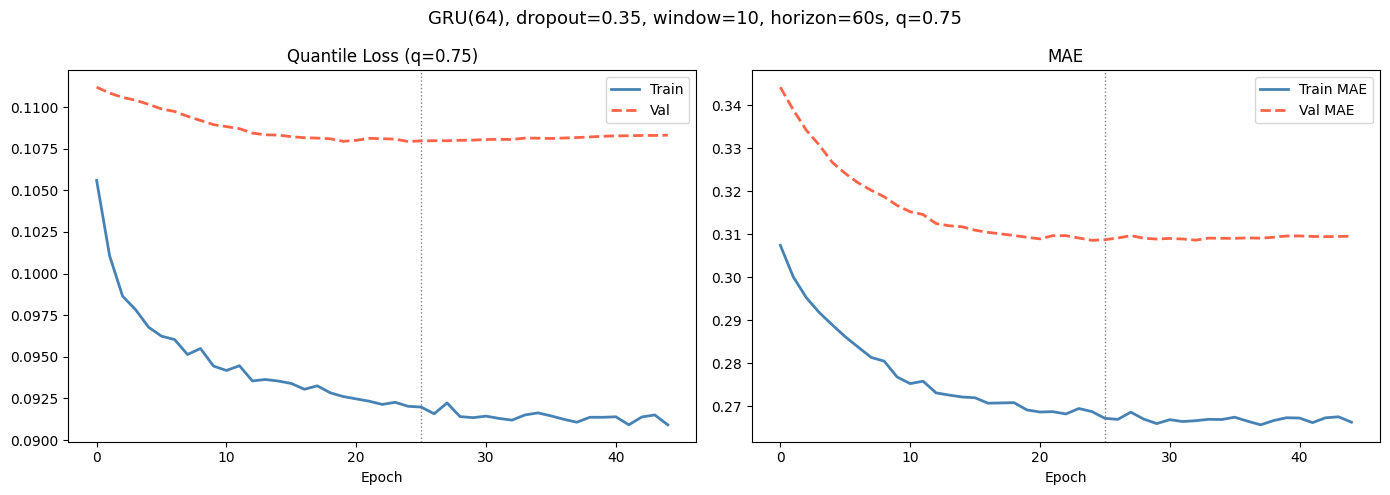

Best epoch: 25  |  Best val_loss: 0.10794


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato', linestyle='--', linewidth=2)
axes[0].set_title(f'Quantile Loss (q={QUANTILE})')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--', linewidth=2)
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
for ax in axes:
    ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1, label=f'best epoch={best_epoch}')

plt.suptitle(f'GRU({LAYER_SIZE}), dropout={DROPOUT_RATE}, window={WINDOW_SIZE}, horizon={FORECAST_HORIZON*5}s, q={QUANTILE}', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best epoch: {best_epoch}  |  Best val_loss: {best_val:.5f}')


## Збереження артефактів

Фінальна модель тренується на **100% даних** з кількістю епох = best_epoch з валідації.

In [21]:
prod_scaler_X = StandardScaler()

X_full_sc = prod_scaler_X.fit_transform(raw_train[:, :N_MODEL_FEAT])
y_full    = raw_train[:, N_MODEL_FEAT]
X_full, y_full = create_sequences(X_full_sc, y_full.reshape(-1, 1), WINDOW_SIZE)

final_model = build_model(
    window_size=WINDOW_SIZE,
    n_features=N_MODEL_FEAT,
    layer_size=LAYER_SIZE,
    dropout_rate=DROPOUT_RATE,
    lr=LEARNING_RATE,
    l2_reg=L2_REG,
    quantile=QUANTILE,
)

final_model.fit(
    X_full, y_full,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    verbose=1,
)

final_model.save('default.keras')
joblib.dump(prod_scaler_X, 'default.joblib')

model_config = {
    'window_size':      WINDOW_SIZE,
    'forecast_horizon': FORECAST_HORIZON,
    'features':         FEATURES,
    'model_type':       'gru',
    'layer_size':       LAYER_SIZE,
    'dropout':          DROPOUT_RATE,
    'l2_reg':           L2_REG,
    'cpu_limit':        CPU_LIMIT,
    'output_type':      'utilization',
    'quantile':         QUANTILE,
}
with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('Збережено:')
print('  default.keras')
print('  default.joblib')
print('  model_config.json')
print(f'\n{json.dumps(model_config, indent=2)}')


Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1095 - mae: 0.3188
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1036 - mae: 0.3082
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1006 - mae: 0.3023
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0984 - mae: 0.2974
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0983 - mae: 0.2948
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0972 - mae: 0.2903
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0963 - mae: 0.2861
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0962 - mae: 0.2842
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0954 - mae: 0.2807
Epoch 10/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0954 - mae: 0.2787
Epoch 11/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0946 - mae: 0.2766
Epoch 12/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0943 - mae: 0.2746
Epoch 13/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

## Оцінка на валідаційному наборі (симуляція реального часу)

In [22]:
# Модель напряму предиктить utilization [0, 1] — scaler_y не потрібен

X_eval_sc = scaler_X.transform(raw_val[:, :N_MODEL_FEAT])
y_eval    = raw_val[:, N_MODEL_FEAT]
X_eval, y_eval_seq = create_sequences(X_eval_sc, y_eval.reshape(-1, 1), WINDOW_SIZE)

y_pred_util = model.predict(X_eval, verbose=0).flatten()
y_true_util = y_eval_seq.flatten()

# Конвертуємо в millicores для порівнянності
actual_peak_m = y_true_util * CPU_LIMIT * 1000
pred_peak_m   = y_pred_util * CPU_LIMIT * 1000

mae_m  = np.mean(np.abs(actual_peak_m - pred_peak_m))
rmse_m = np.sqrt(np.mean((actual_peak_m - pred_peak_m) ** 2))
bias_m = np.mean(pred_peak_m - actual_peak_m)
underpred_pct = np.mean(pred_peak_m < actual_peak_m) * 100

print(f'Метрики на val (абсолютні піки CPU, без safety factor):')
print(f'  MAE:       {mae_m:.1f} m')
print(f'  RMSE:      {rmse_m:.1f} m')
print(f'  Bias:      {bias_m:+.1f} m  ({"завищує" if bias_m > 0 else "занижує"})')
print(f'  Underpred: {underpred_pct:.1f}%  (ціль: < 20%)')
print(f'\nUtilization range — pred: [{y_pred_util.min():.3f}, {y_pred_util.max():.3f}]')
print(f'Utilization range — true: [{y_true_util.min():.3f}, {y_true_util.max():.3f}]')


Метрики на val (абсолютні піки CPU, без safety factor):
  MAE:       617.2 m
  RMSE:      715.8 m
  Bias:      +390.5 m  (завищує)
  Underpred: 19.8%  (ціль: < 20%)

Utilization range — pred: [0.183, 0.787]
Utilization range — true: [0.001, 0.811]


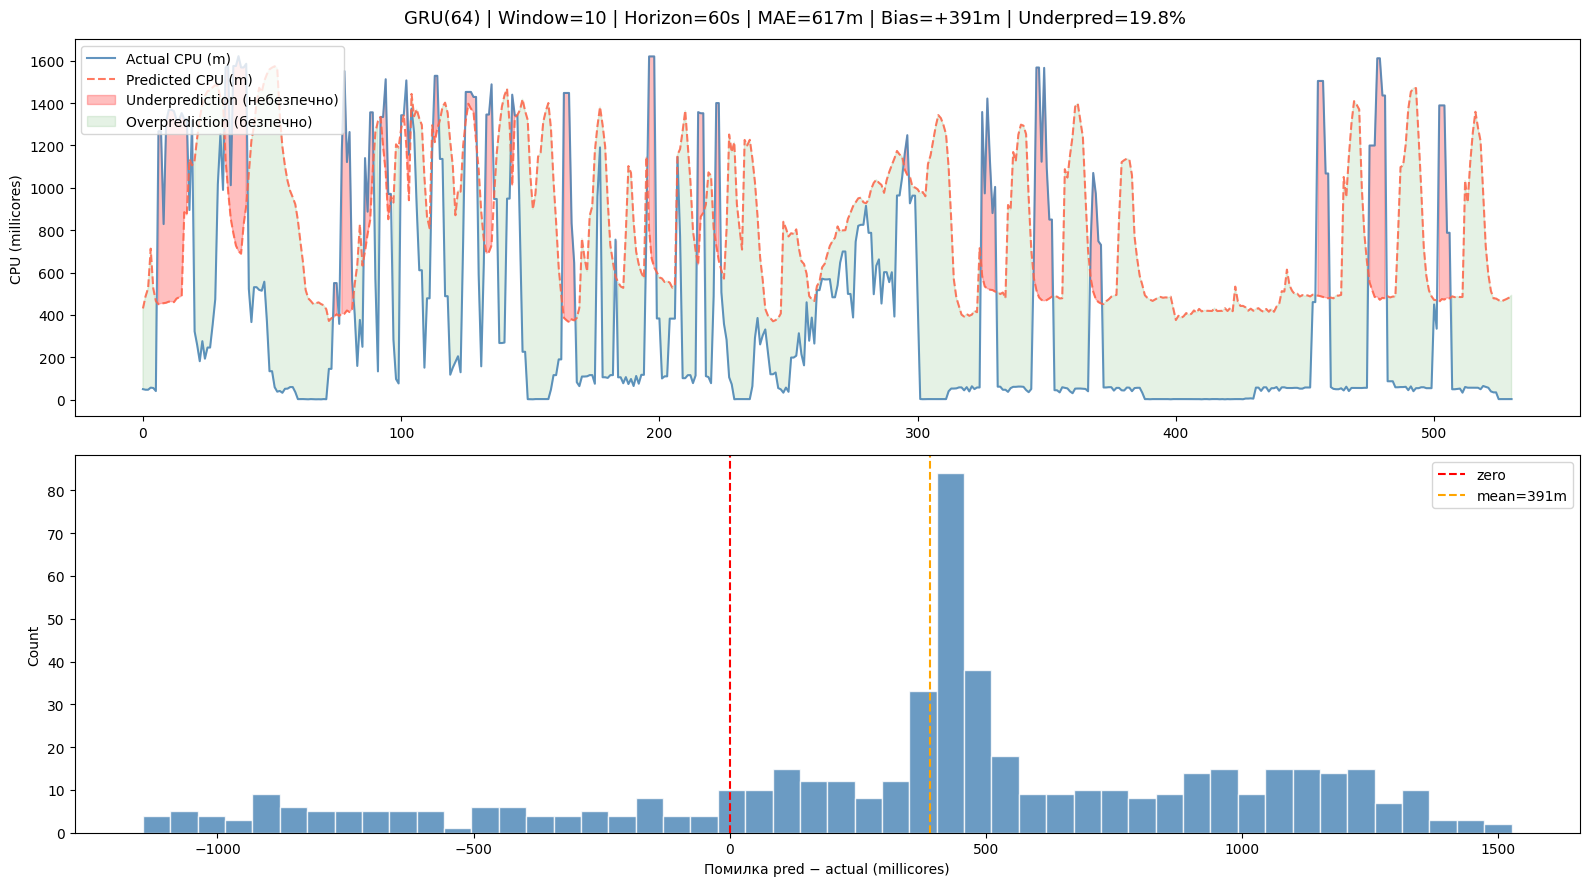

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle(
    f'GRU({LAYER_SIZE}) | Window={WINDOW_SIZE} | Horizon={FORECAST_HORIZON*5}s | '
    f'MAE={mae_m:.0f}m | Bias={bias_m:+.0f}m | Underpred={underpred_pct:.1f}%',
    fontsize=13
)

idx = np.arange(len(actual_peak_m))
axes[0].plot(idx, actual_peak_m, label='Actual CPU (m)',    color='steelblue',  linewidth=1.5, alpha=0.85)
axes[0].plot(idx, pred_peak_m,   label='Predicted CPU (m)', color='tomato', linestyle='--', linewidth=1.5, alpha=0.85)
axes[0].fill_between(idx, actual_peak_m, pred_peak_m,
    where=(pred_peak_m < actual_peak_m), alpha=0.25, color='red',   label='Underprediction (небезпечно)')
axes[0].fill_between(idx, actual_peak_m, pred_peak_m,
    where=(pred_peak_m >= actual_peak_m), alpha=0.1, color='green', label='Overprediction (безпечно)')
axes[0].set_ylabel('CPU (millicores)')
axes[0].legend(loc='upper left')

err_m = pred_peak_m - actual_peak_m
axes[1].hist(err_m, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,           color='red',    linestyle='--', linewidth=1.5, label='zero')
axes[1].axvline(err_m.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'mean={err_m.mean():.0f}m')
axes[1].set_xlabel('Помилка pred − actual (millicores)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('inference_simulation.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# === Sanity check: що модель предиктить на idle вході? ===

idle_cpu = np.full(9, 0.002)
idle_rps = np.zeros(9)

pct_cpu   = (idle_cpu[1:] - idle_cpu[:-1]) / (idle_cpu[:-1] + EPS)
pct_rps   = (idle_rps[1:] - idle_rps[:-1]) / (idle_rps[:-1] + EPS)
cpu_level = idle_cpu[1:]
rps_level = np.log1p(idle_rps[1:])   # log(0+1) = 0

X_idle = np.column_stack([pct_cpu, pct_rps, cpu_level, rps_level])
pred_idle = model.predict(scaler_X.transform(X_idle)[np.newaxis], verbose=0)[0, 0]

print(f"Idle input  → cpu_level=0.002, rps_level=0.0 (rps=0)")
print(f"Prediction  → {pred_idle:.4f}  ({pred_idle*100:.1f}%)")
print(f"KEDA replicas → ceil({pred_idle*100:.1f} / 35) = {int(np.ceil(pred_idle*100/35))}")
print()

# Весь діапазон: фіксований rps=0 (idle), cpu_level від 0 до 0.8
print("--- rps=0 (idle) ---")
print("cpu_level  →  prediction  →  replicas")
for lvl in np.linspace(0.002, 0.8, 8):
    x = np.column_stack([np.zeros(8), np.zeros(8), np.full(8, lvl), np.zeros(8)])
    p = model.predict(scaler_X.transform(x)[np.newaxis], verbose=0)[0, 0]
    print(f"  {lvl:.3f}  →  {p:.4f} ({p*100:.1f}%)  →  {int(np.ceil(p*100/35))} replicas")

print()
# Фіксований rps=10 (середнє навантаження)
print("--- rps=10 (навантаження) ---")
print("cpu_level  →  prediction  →  replicas")
for lvl in np.linspace(0.1, 0.8, 8):
    rps_val = np.log1p(10)
    x = np.column_stack([np.zeros(8), np.zeros(8), np.full(8, lvl), np.full(8, rps_val)])
    p = model.predict(scaler_X.transform(x)[np.newaxis], verbose=0)[0, 0]
    print(f"  {lvl:.3f}  →  {p:.4f} ({p*100:.1f}%)  →  {int(np.ceil(p*100/35))} replicas")


Idle input  → cpu_level=0.002, rps_level=0.0 (rps=0)
Prediction  → 0.2037  (20.4%)
KEDA replicas → ceil(20.4 / 35) = 1

--- rps=0 (idle) ---
cpu_level  →  prediction  →  replicas
  0.002  →  0.2037 (20.4%)  →  1 replicas
  0.116  →  0.2480 (24.8%)  →  1 replicas
  0.230  →  0.2997 (30.0%)  →  1 replicas
  0.344  →  0.3574 (35.7%)  →  2 replicas
  0.458  →  0.4192 (41.9%)  →  2 replicas
  0.572  →  0.4825 (48.2%)  →  2 replicas
  0.686  →  0.5445 (54.4%)  →  2 replicas
  0.800  →  0.6027 (60.3%)  →  2 replicas

--- rps=10 (навантаження) ---
cpu_level  →  prediction  →  replicas
  0.100  →  0.3772 (37.7%)  →  2 replicas
  0.200  →  0.4348 (43.5%)  →  2 replicas
  0.300  →  0.4941 (49.4%)  →  2 replicas
  0.400  →  0.5529 (55.3%)  →  2 replicas
  0.500  →  0.6090 (60.9%)  →  2 replicas
  0.600  →  0.6606 (66.1%)  →  2 replicas
  0.700  →  0.7066 (70.7%)  →  3 replicas
  0.800  →  0.7467 (74.7%)  →  3 replicas
